In [ ]:
# Dataset: https://drive.google.com/file/d/1kunOp2mSPbyp1rtImBDI7XPcU7xAiKI5/view?usp=sharing

In [ ]:
!unzip /content/lettuce_health_dataset.zip -d /content/

Archive:  /content/lettuce_health_dataset.zip
   creating: /content/lettuce_health_dataset/
   creating: /content/lettuce_health_dataset/healthy/
  inflating: /content/lettuce_health_dataset/healthy/H_00002.jpg  
  inflating: /content/lettuce_health_dataset/healthy/H_00004.jpg  
  inflating: /content/lettuce_health_dataset/healthy/H_00005.jpg  
  inflating: /content/lettuce_health_dataset/healthy/H_00007.jpg  
  inflating: /content/lettuce_health_dataset/healthy/H_00008.jpg  
  inflating: /content/lettuce_health_dataset/healthy/H_00009.jpg  
  inflating: /content/lettuce_health_dataset/healthy/H_00011.jpg  
  inflating: /content/lettuce_health_dataset/healthy/H_00012.jpg  
  inflating: /content/lettuce_health_dataset/healthy/H_00013.jpg  
  inflating: /content/lettuce_health_dataset/healthy/H_00014.jpg  
  inflating: /content/lettuce_health_dataset/healthy/H_00015.jpg  
  inflating: /content/lettuce_health_dataset/healthy/H_00016.jpg  
  inflating: /content/lettuce_health_dataset/healt

In [1]:
from PIL import Image
from keras.utils import image_dataset_from_directory
from keras.applications import ResNet50, InceptionV3, MobileNetV3Large, EfficientNetB3, ResNet101, VGG19
from keras import models, layers
from keras.losses import BinaryCrossentropy
from keras.optimizers import Adam
from keras import callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from keras import Model
from keras.regularizers import l2

from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from PIL import Image
from IPython.display import display

import matplotlib.pyplot as plt
import os
import numpy as np
import random
import pandas as pd
import math
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
DATA_PATH = '/content/lettuce_health_dataset'
CLASS_NAMES = ['healthy', 'unhealthy']
TEST_SIZE = 0.1
VALID_SIZE = 0.1
BATCH_SIZE=16
EPOCHS=30
IMAGE_SIZE=224

In [ ]:
print('Number of healthy image: ', len(os.listdir(f'{DATA_PATH}/healthy')))
print('Number of unhealthy image: ', len(os.listdir(f'{DATA_PATH}/unhealthy')))

Number of healthy image:  1156
Number of unhealthy image:  1084


In [ ]:
widths = []
heights = []
for class_name in os.listdir(DATA_PATH):
    for file_name in os.listdir(f'{DATA_PATH}/{class_name}'):
        img_path = os.path.join(DATA_PATH, class_name, file_name)
        img = Image.open(img_path)
        w, h = img.size
        widths.append(w)
        heights.append(h)

avg_width = np.mean(widths)
avg_height = np.mean(heights)

print(f"Kich thuoc trung binh cua dataset: {avg_width:.2f} x {avg_height:.2f}")

Kich thuoc trung binh cua dataset: 638.35 x 630.56


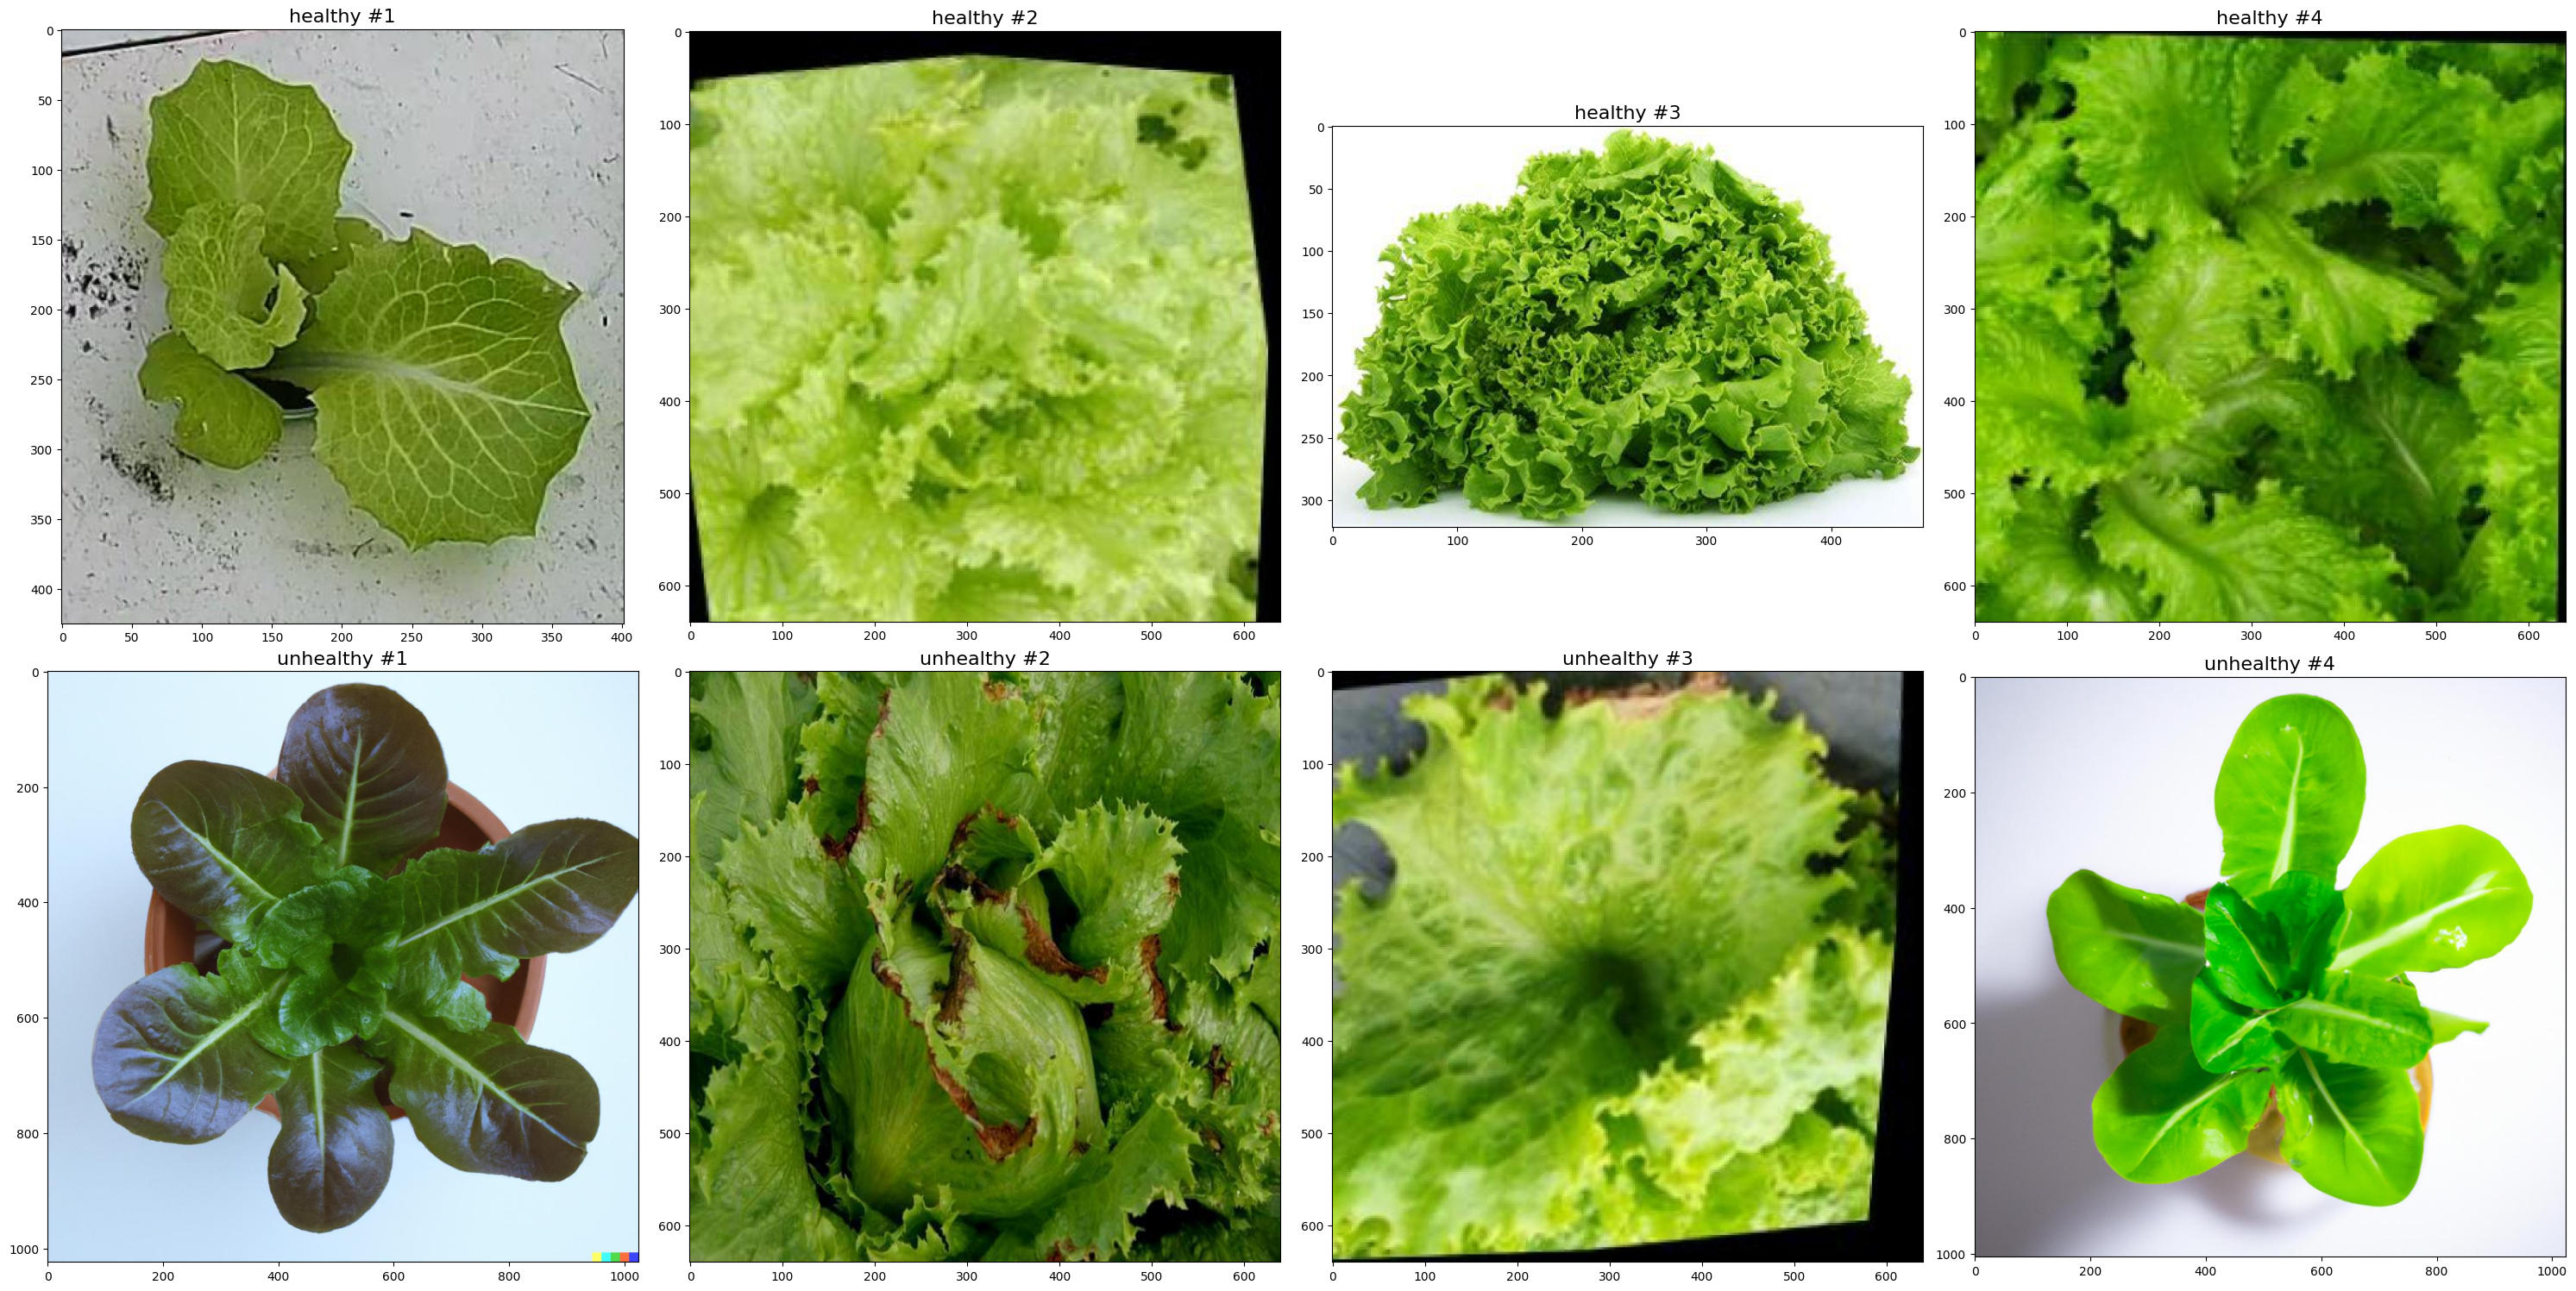

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(30, 15))
for i, class_name in enumerate(os.listdir(DATA_PATH)):
    random_idx = random.sample(range(1, 1083), 4)
    for j, idx in enumerate(random_idx):
        file_name = os.listdir(f'{DATA_PATH}/{class_name}')[idx]
        image_path = os.path.join(DATA_PATH, class_name, file_name)
        image = Image.open(image_path).convert('RGB')
        ax[i, j].imshow(image)
        ax[i, j].set_title(f"{class_name} #{j+1}", fontsize=16)

plt.tight_layout()
plt.show()

In [ ]:
img_paths = []
labels = []

for class_name in os.listdir(DATA_PATH):
    for img in os.listdir(f'{DATA_PATH}/{class_name}'):
        img_paths.append(f'{DATA_PATH}/{class_name}/{img}')
        labels.append(class_name)

df = pd.DataFrame({"img_path": img_paths, "label": labels})

In [ ]:
df_train, X_test = train_test_split(df, test_size=TEST_SIZE, stratify=df['label'], random_state=42)
X_train, X_val = train_test_split(df_train, test_size=VALID_SIZE, stratify=df_train['label'], random_state=42)

In [ ]:
print(len(X_train), len(X_test), len(X_val))

1814 224 202


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    brightness_range=[0.8, 1.3],
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_set = train_datagen.flow_from_dataframe(
    X_train,
    x_col='img_path',
    y_col='label',
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb',
    classes=CLASS_NAMES,
    shuffle=True
)

val_set = val_datagen.flow_from_dataframe(
    X_val,
    x_col='img_path',
    y_col='label',
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb',
    classes=CLASS_NAMES,
)

Found 1814 validated image filenames belonging to 2 classes.
Found 202 validated image filenames belonging to 2 classes.


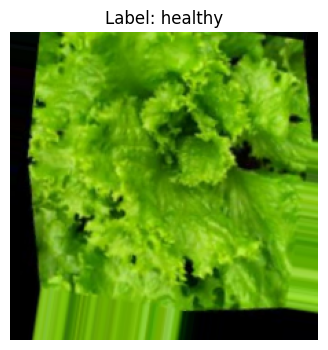

In [ ]:
images, labels = next(train_set)
idx = np.random.randint(0, len(images))
img = images[idx]
label = labels[idx]

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title(f"Label: {CLASS_NAMES[int(label)]}")
plt.axis("off")
plt.show()

In [ ]:
# base_model = VGG19(include_top=False, input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), weights="imagenet")
# base_model.summary()

In [ ]:
# =================================== VGG19 ===================================
vgg19 = VGG19(include_top=False, input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), weights="imagenet")
vgg19.trainable=False
for layer in vgg19.layers[-10:]:
    layer.trainable = True

fine_tune_vgg19 = models.Sequential([
    vgg19,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu', kernel_regularizer=l2(1e-5)),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# =================================== InceptionV3 ===================================
inceptionv3 = InceptionV3(include_top=False, input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), weights="imagenet")

fine_tune_inceptionv3 = models.Sequential([
    inceptionv3,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# =================================== ResNet50 ===================================
resnet50 = ResNet50(include_top=False, input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), weights="imagenet")
resnet50.trainable = False

for layer in resnet50.layers[-100:]:
    layer.trainable = True

fine_tune_resnet50 = models.Sequential([
    resnet50,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu', kernel_regularizer=l2(1e-4)),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

In [ ]:
models_dict = {}
histories_dict = {}
best_val_acc = 0
best_model_name = None
best_model = None

learning_rates = [5e-6, 1e-5, 1e-5]
list_name = ['VGG19', 'InceptionV3', 'ResNet50']
list_model = [fine_tune_vgg19, fine_tune_inceptionv3, fine_tune_resnet50]

for name, model, lr  in zip(list_name, list_model, learning_rates):
    print(f'\n\n================================= Training model: {name} =================================')

    model.compile(loss=BinaryCrossentropy(),
                  optimizer=Adam(learning_rate=lr),
                  metrics=['accuracy'])


    earlystopping = callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True
    )

    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )

    history = model.fit(
        train_set,
        validation_data=val_set,
        epochs=EPOCHS,
        callbacks=[earlystopping, reduce_lr]
    )

    models_dict[name] = model
    histories_dict[name] = history.history
    val_acc = max(history.history['val_accuracy'])

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_name = name
        best_model = model

print(f"\n\nModel: {best_model_name}")
print(f"Best validation accuracy: {best_val_acc:.4f}")



================================= Training model: VGG19 =================================
Epoch 1/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 80s 540ms/step - accuracy: 0.5177 - loss: 0.7427 - val_accuracy: 0.7178 - val_loss: 0.6025 - learning_rate: 5.0000e-06
Epoch 2/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 44s 383ms/step - accuracy: 0.7016 - loss: 0.5709 - val_accuracy: 0.7871 - val_loss: 0.4526 - learning_rate: 5.0000e-06
Epoch 3/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 44s 389ms/step - accuracy: 0.7868 - loss: 0.4553 - val_accuracy: 0.8465 - val_loss: 0.3748 - learning_rate: 5.0000e-06
Epoch 4/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 44s 383ms/step - accuracy: 0.8167 - loss: 0.4037 - val_accuracy: 0.8168 - val_loss: 0.3762 - learning_rate: 5.0000e-06
Epoch 5/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.8747 - loss: 0.2996
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
114/114 ━━━━━━━━━━━━━━━━━━━━ 44s 387ms/step - accuracy: 0.8745 - loss: 0.2999 - val_accuracy: 0.8020 - val_l

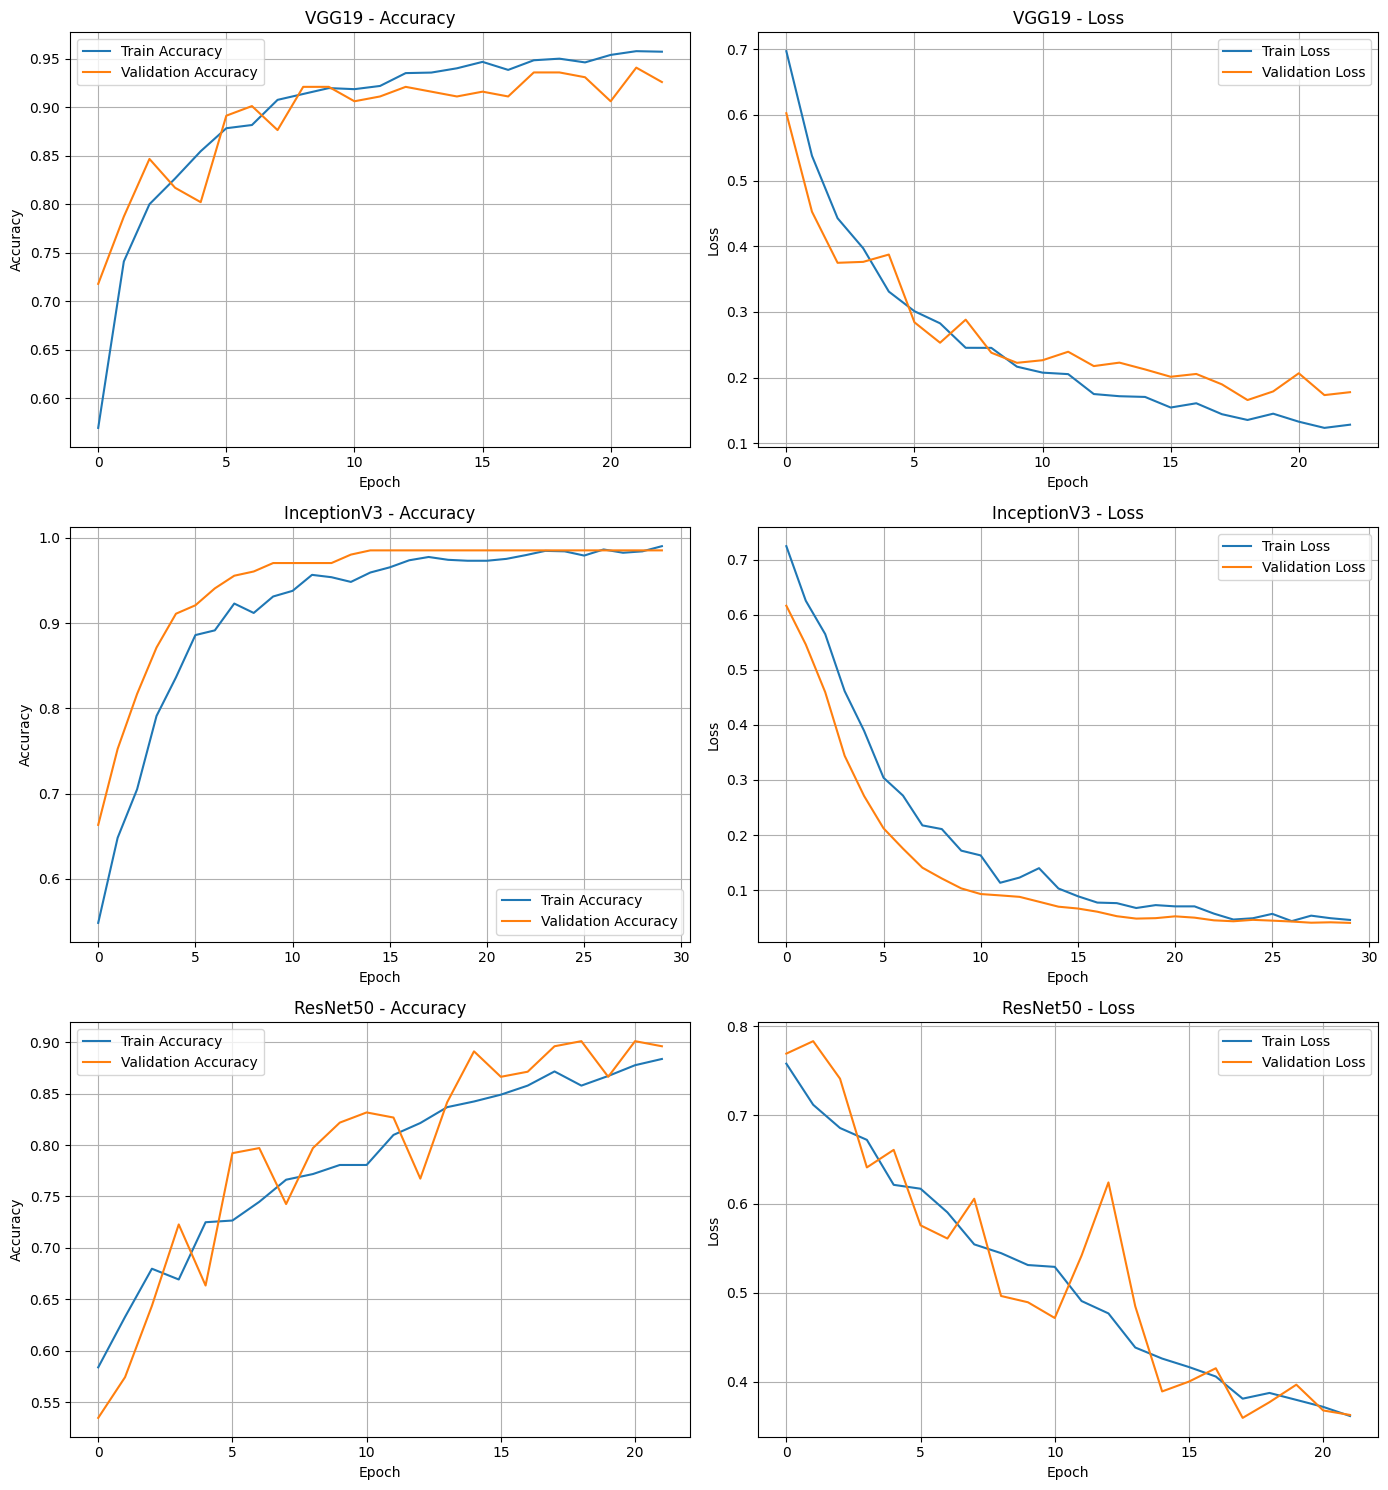

In [ ]:
fig, ax = plt.subplots(nrows=len(histories_dict), ncols=2, figsize=(14, 5 * len(histories_dict)))
ax = ax.reshape(len(histories_dict), 2)

for i, (name, history) in enumerate(histories_dict.items()):
    ax[i, 0].plot(history['accuracy'], label='Train Accuracy')
    ax[i, 0].plot(history['val_accuracy'], label='Validation Accuracy')
    ax[i, 0].set_title(f'{name} - Accuracy')
    ax[i, 0].set_xlabel('Epoch')
    ax[i, 0].set_ylabel('Accuracy')
    ax[i, 0].legend()
    ax[i, 0].grid(True)

    ax[i, 1].plot(history['loss'], label='Train Loss')
    ax[i, 1].plot(history['val_loss'], label='Validation Loss')
    ax[i, 1].set_title(f'{name} - Loss')
    ax[i, 1].set_xlabel('Epoch')
    ax[i, 1].set_ylabel('Loss')
    ax[i, 1].legend()
    ax[i, 1].grid(True)

plt.tight_layout()
plt.show()


In [ ]:
test_set = ImageDataGenerator(rescale=1./255).flow_from_dataframe(
    X_test,
    x_col='img_path',
    y_col='label',
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    classes=CLASS_NAMES
)

Found 224 validated image filenames belonging to 2 classes.




============= Evaluating model: VGG19 =============
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step
Accuracy: 0.9330

Classification Report:
              precision    recall  f1-score   support

     healthy       0.91      0.97      0.94       116
   unhealthy       0.96      0.90      0.93       108

    accuracy                           0.93       224
   macro avg       0.94      0.93      0.93       224
weighted avg       0.93      0.93      0.93       224



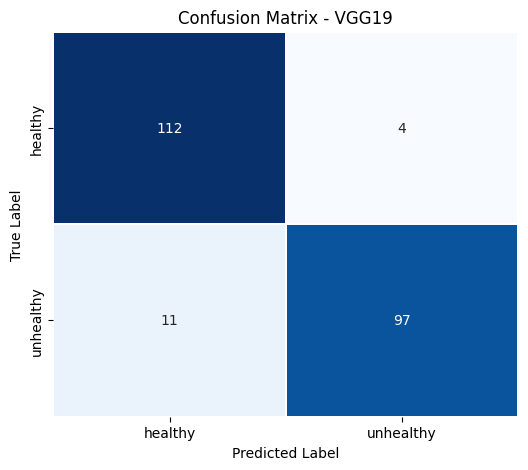



============= Evaluating model: InceptionV3 =============
14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step
Accuracy: 0.9955

Classification Report:
              precision    recall  f1-score   support

     healthy       0.99      1.00      1.00       116
   unhealthy       1.00      0.99      1.00       108

    accuracy                           1.00       224
   macro avg       1.00      1.00      1.00       224
weighted avg       1.00      1.00      1.00       224



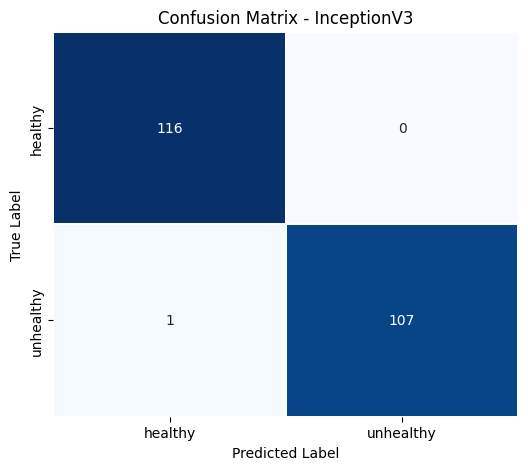



============= Evaluating model: ResNet50 =============
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step
Accuracy: 0.8929

Classification Report:
              precision    recall  f1-score   support

     healthy       0.90      0.90      0.90       116
   unhealthy       0.89      0.89      0.89       108

    accuracy                           0.89       224
   macro avg       0.89      0.89      0.89       224
weighted avg       0.89      0.89      0.89       224



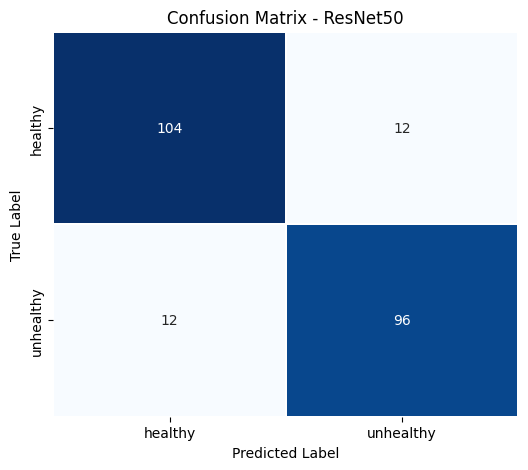

In [ ]:
for name, model in models_dict.items():
    print(f'\n\n============= Evaluating model: {name} =============')
    y_true = test_set.classes
    y_pred = model.predict(test_set, verbose=1)
    y_pred_labels = (y_pred > 0.5).astype(int).flatten()

    acc = accuracy_score(y_true, y_pred_labels)
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred_labels, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_true, y_pred_labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                linewidths=0.3, xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

In [ ]:
best_model.save(f'{best_model_name}_lettuce_health_classification.keras')

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.applications.inception_v3 import preprocess_input
from PIL import Image

model = load_model('/content/InceptionV3_lettuce_health_classification.keras')

In [29]:
base_model = model.layers[0]

conv_layers = [layer for layer in base_model.layers if 'conv' in layer.name]
num_layers = len(conv_layers)

selected_layers = [
    conv_layers[0],
    conv_layers[1],
    conv_layers[num_layers // 2 - 1],
    conv_layers[num_layers // 2],
    conv_layers[-1]
]

layer_outputs = [layer.output for layer in selected_layers]
activation_model = Model(inputs=base_model.input, outputs=layer_outputs)

def visualize_feature_maps(img_path, num_filters=6, title_prefix="InceptionV3"):
    image = Image.open(img_path).convert('RGB')
    image = image.resize((224, 224))
    img_np = np.array(image)

    plt.imshow(img_np)
    plt.show()

    img_np = np.expand_dims(img_np, axis=0)
    img_np = preprocess_input(img_np)

    activations = activation_model.predict(img_np)

    plt.figure(figsize=(10, 10))
    for layer_idx, layer in enumerate(selected_layers):
        feature_maps = activations[layer_idx][0]
        layer_name = layer.name

        num_display = min(num_filters, feature_maps.shape[-1])

        for f in range(num_display):
            ax = plt.subplot(len(selected_layers), num_display, layer_idx * num_display + f + 1)
            plt.imshow(feature_maps[:, :, f], cmap='viridis')
            plt.axis('off')
            if layer_idx == 0:
                plt.title(f'F{f+1}', fontsize=8)
            if f == 0:
                plt.ylabel(layer_name, fontsize=8, rotation=0, labelpad=40)

    plt.suptitle(f'{title_prefix} - Feature Maps', fontsize=14)
    plt.tight_layout()
    plt.show()

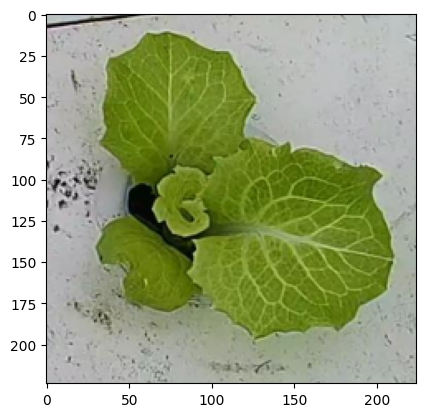

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


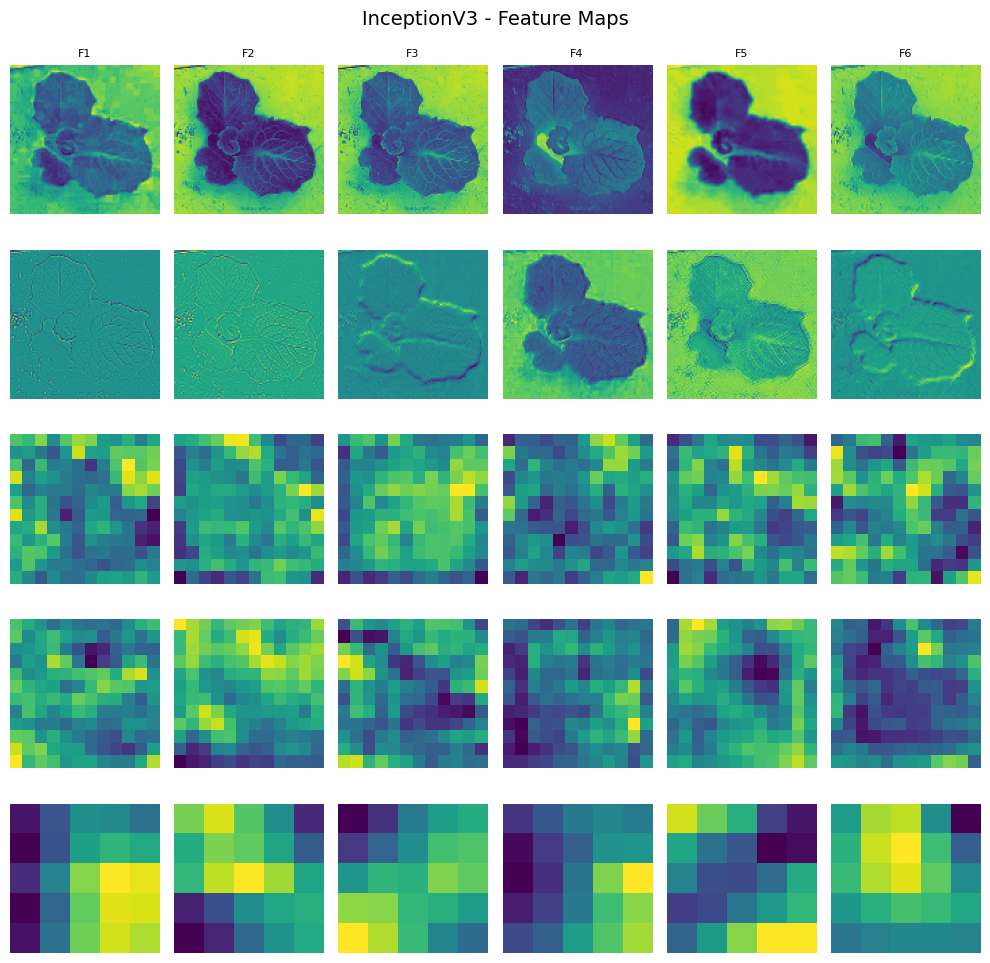

In [30]:
visualize_feature_maps('/content/H_01239.jpg')

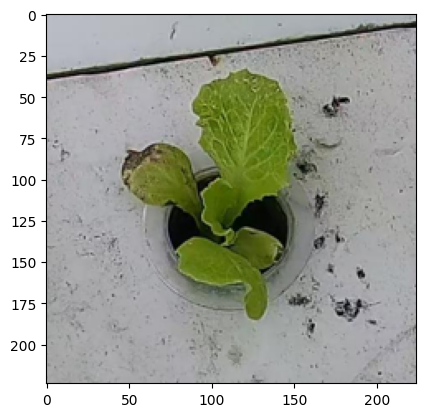

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step


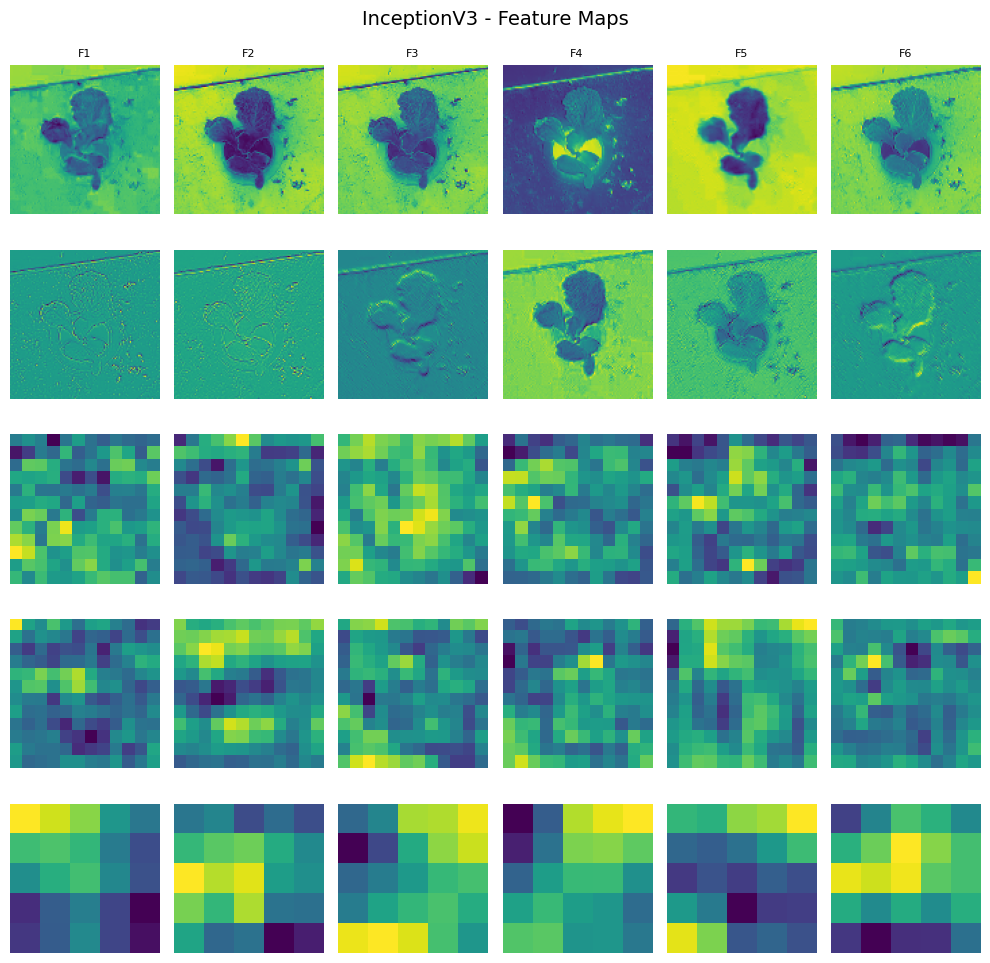

In [31]:
visualize_feature_maps('/content/D_01206.jpg')

In [ ]:
# # Khoi tao k-fold
# kf = KFold(n_splits=6, shuffle=True, random_state=42)

# train_datagen = ImageDataGenerator(
#     rescale=1./255,
#     rotation_range=20,
#     width_shift_range=0.2,
#     height_shift_range=0.2,
#     brightness_range=[0.5, 1.5],
#     zoom_range=0.2,
#     horizontal_flip=True,
#     )

# val_datagen = ImageDataGenerator(rescale=1./255)

# fold_idx=1
# histories=[]
# best_val_acc=0

# for train_index, val_index in kf.split(x_train):
#     if fold_idx > 3:
#         break
#     print(f'====================================================================')
#     print(f'                            Folk {fold_idx}')
#     print(f'====================================================================')

#     df_train = x_train.iloc[train_index]
#     df_val = x_train.iloc[val_index]

#     train_gen = train_datagen.flow_from_dataframe(
#         df_train,
#         x_col='img_path',
#         y_col='label',
#         target_size=(IMAGE_SIZE, IMAGE_SIZE),
#         batch_size=BATCH_SIZE,
#         class_mode='binary',
#         color_mode='rgb',
#         classes=CLASS_NAMES,
#         shuffle=True
#     )

#     val_gen = val_datagen.flow_from_dataframe(
#         df_val,
#         x_col='img_path',
#         y_col='label',
#         target_size=(IMAGE_SIZE, IMAGE_SIZE),
#         batch_size=BATCH_SIZE,
#         class_mode='binary',
#         color_mode='rgb',
#         classes=CLASS_NAMES,
#     )

#     model_kfold=create_model()

#     model_kfold.compile(loss=BinaryCrossentropy(),
#                         optimizer=Adam(learning_rate=1e-5),
#                         metrics=['accuracy'])

#     def scheduler(epoch, lr):
#         if epoch < 10:
#             return lr
#         else:
#             return lr * math.exp(-0.1)

#     earlystopping=callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
#     lr_schedule=callbacks.LearningRateScheduler(scheduler)

#     history = model_kfold.fit(
#         train_gen,
#         validation_data=val_gen,
#         epochs=EPOCHS,
#         callbacks=[earlystopping, lr_schedule]
#     )

#     val_acc = max(history.history['val_accuracy'])
#     if val_acc > best_val_acc:
#         best_val_acc = val_acc
#         best_model = model_kfold

#     histories.append(history)
#     fold_idx += 1

# train_accuracies = []
# val_accuracies = []
# train_losses = []
# val_losses = []

# for i, history in enumerate(histories):
#     train_accuracies.append(history.history['accuracy'][-1])
#     val_accuracies.append(history.history['val_accuracy'][-1])
#     train_losses.append(history.history['loss'][-1])
#     val_losses.append(history.history['val_loss'][-1])

# print(f"Average Train Accuracy: {np.mean(train_accuracies):.4f} ± {np.std(train_accuracies):.4f}")
# print(f"Average Validation Accuracy: {np.mean(val_accuracies):.4f} ± {np.std(val_accuracies):.4f}")
# print(f"Average Train Loss: {np.mean(train_losses):.4f} ± {np.std(train_losses):.4f}")
# print(f"Average Validation Loss: {np.mean(val_losses):.4f} ± {np.std(val_losses):.4f}")